**Business Problem:**
A real estate company wants to optimize its property pricing strategy and improve the efficiency of its sales process. They have collected detailed property listing data including location, size, amenities, and pricing.

# Terminologies
**Carpet Area** : The carpet area is the actual usable area inside a flat or house, measured wall-to-wall where you can lay a carpet.

**Super Build Up Area** : The Super Built-up Area is the total saleable area of a property. It includes the built-up area of the flat + a proportionate share of common areas in the building.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import re
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\real_estates1.csv") # Reading Data Set 

In [5]:
df.columns # Column of Data Frame 

Index(['bhk', 'price', 'price_per_sqft', 'super_built_up_area', 'carpet_area',
       'bedroom', 'bathroom', 'balconies', 'status', 'transaction_type',
       'funrished_status', 'address', 'facing', 'floorNum', 'projectName',
       'additional_room', 'amenities', 'localities', 'regions', 'lats',
       'longs'],
      dtype='object')

In [6]:
df.duplicated().sum() # checking the duplicates 

2351

In [7]:
df = df.drop_duplicates() # Droping the duplicates 

In [8]:
df.info() # Information about Columns and Data Types 

<class 'pandas.core.frame.DataFrame'>
Index: 19352 entries, 0 to 21701
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bhk                  19352 non-null  object 
 1   price                18582 non-null  object 
 2   price_per_sqft       18386 non-null  object 
 3   super_built_up_area  6559 non-null   object 
 4   carpet_area          11884 non-null  object 
 5   bedroom              18543 non-null  float64
 6   bathroom             17848 non-null  float64
 7   balconies            8505 non-null   float64
 8   status               15802 non-null  object 
 9   transaction_type     18573 non-null  object 
 10  funrished_status     16883 non-null  object 
 11  address              18582 non-null  object 
 12  facing               10672 non-null  object 
 13  floorNum             15746 non-null  object 
 14  projectName          11830 non-null  object 
 15  additional_room      4733 non-null   obje

In [9]:
df.head() # Returns Top 5 rows of Data Frame 

,bhk,price,price_per_sqft,super_built_up_area,carpet_area,bedroom,bathroom,balconies,status,transaction_type,...,address,facing,floorNum,projectName,additional_room,amenities,localities,regions,lats,longs
0,3-bhk-1377-sq-ft-multistorey-apartment-for-sal...,"₹52 Lac | ₹2,91,199 Approx. Registration Charges","₹4,333/sqft",NaN,1200,3.0,2.0,NaN,Ready to Move,Resale,...,Kammasandra Main Road Shree Ananth Nagar Layou...,North,4(Out of 5 Floors),NaN,NaN,NaN,Electronic City Phase 2,Bangalore,12.839136,77.698975
1,4-bhk-3022-sq-ft-villa-for-sale-sarjapur-road-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3-bhk-1608-sq-ft-multistorey-apartment-for-sal...,₹1.64 Cr,"₹10,217/sqft",1608,NaN,3.0,3.0,NaN,Under Construction,New Property,...,"Sarjapur Road, Bangalore - South, Karnataka",NaN,NaN,DSR The Address,NaN,Pool with temperature control Golf Course High...,Sarjapur Road,Bangalore,12.912350,77.680996
3,2-bhk-1417-sq-ft-multistorey-apartment-for-sal...,"₹1.41 Cr | ₹7,95,152 Approx. Registration Char...","₹14,915/sqft",NaN,952,2.0,2.0,2.0,Ready to Move,New Property,...,"Begur - Koppa Rd, Suraksha nagar, Yelenahalli,...",West,4(Out of 18 Floors),NaN,NaN,NaN,Begur Hulimavu Road,Bangalore,12.865125,77.621071
4,3-bhk-1410-sq-ft-multistorey-apartment-for-sal...,"₹67 Lac | ₹3,75,199 Approx. Registration Charges","₹4,751/sqft",1410,NaN,3.0,2.0,NaN,Ready to Move,New Property,...,"Electronic City, Bangalore, Electronics City P...",East,1(Out of 4 Floors),Sri Sai Nandana Royal,NaN,Power Back Up Lift Rain Water Harvesting Gymna...,Electronics City Phase 1,Bangalore,12.833951,77.675366


In [10]:
df['address']

0        Kammasandra Main Road Shree Ananth Nagar Layou...
1                                                      NaN
2              Sarjapur Road, Bangalore - South, Karnataka
3        Begur - Koppa Rd, Suraksha nagar, Yelenahalli,...
4        Electronic City, Bangalore, Electronics City P...
                               ...                        
21696    Godrej United, Whitefield, Bangalore - East, K...
21697    flat no 106 first floor A block Parimala Trini...
21698    10th Street, Ashirvad Colony, Bangalore - East...
21699          Budigere Cross, Bangalore - East, Karnataka
21701    Akshara Green City, Budigere Cross, Bangalore ...
Name: address, Length: 19352, dtype: object

In [11]:
df.tail() # returns last five rows of Data Frame 

,bhk,price,price_per_sqft,super_built_up_area,carpet_area,bedroom,bathroom,balconies,status,transaction_type,...,address,facing,floorNum,projectName,additional_room,amenities,localities,regions,lats,longs
21696,5-bhk-2956-sq-ft-multistorey-apartment-for-sal...,"₹5.85 Cr | ₹32,75,999 Approx. Registration Cha...","₹19,790/sqft",2956,NaN,5.0,5.0,4.0,Ready to Move,Resale,...,"Godrej United, Whitefield, Bangalore - East, K...",East,16(Out of 17 Floors),Godrej United,NaN,Power Back Up Kids Play Area Cafeteria/Food Co...,Whitefield,Bangalore,12.968048,77.739097
21697,3-bhk-1565-sq-ft-multistorey-apartment-for-sal...,₹1.48 Cr,"₹10,571/sqft",NaN,1400,3.0,3.0,NaN,Ready to Move,Resale,...,flat no 106 first floor A block Parimala Trini...,West,1(Out of 5 Floors),Parimala Trinity,NaN,Power Back Up Waste Disposal Internet/Wi-Fi Co...,Panathur,Bangalore,12.934362,77.704041
21698,4-bhk-2400-sq-ft-residential-house-for-sale-as...,₹1.6 Cr | ₹250 Monthly,"₹6,666/sqft",2400,NaN,4.0,4.0,2.0,Ready to Move,Resale,...,"10th Street, Ashirvad Colony, Bangalore - East...",West,NaN,NaN,1 Study Room,NaN,Ashirvad Colony,Bangalore,13.026572,77.657832
21699,4-bhk-2750-sq-ft-villa-for-sale-budigere-cross...,"₹1.99 Cr | ₹11,14,400 Approx. Registration Cha...","₹7,236/sqft",NaN,2750,4.0,5.0,NaN,Ready to Move,Resale,...,"Budigere Cross, Bangalore - East, Karnataka",NaN,NaN,NaN,1 Store Room,NaN,Budigere Cross,Bangalore,13.046666,77.750076
21701,4-bhk-2300-sq-ft-residential-house-for-sale-bu...,"₹1.55 Cr | ₹8,67,999 Approx. Registration Charges","₹6,739/sqft",2300,NaN,4.0,4.0,2.0,Ready to Move,New Property,...,"Akshara Green City, Budigere Cross, Bangalore ...",West,Upper Basement(Out of 2 Floors),NaN,1 Store Room,NaN,Budigere Cross,Bangalore,13.063881,77.745560


In [12]:
df.isnull().sum() # Checking Null values in Data Frame 

bhk                        0
price                    770
price_per_sqft           966
super_built_up_area    12793
carpet_area             7468
bedroom                  809
bathroom                1504
balconies              10847
status                  3550
transaction_type         779
funrished_status        2469
address                  770
facing                  8680
floorNum                3606
projectName             7522
additional_room        14619
amenities               8998
localities              1157
regions                  770
lats                    1135
longs                   1135
dtype: int64

In [13]:
df.rename(columns = {'funrished_status' : 'Furnished_Status'}, inplace = True)

In [14]:
df['bhk_modified'] = df['bhk'].str.split("", expand = True)[1] 
# Extractiong Bhk's from BHK Column 

In [15]:
df['Residency_Type'] = df['bhk'].str.split("-", expand =True)[5] + " " + df['bhk'].str.split("-", expand =True)[6]
# Extracting Residency type from BHK column 

In [16]:
df['Residency_Type'].unique()
# Unique Values from Residency Column 

array(['multistorey apartment', 'villa for', 'builder floor',
       'residential house', 'penthouse for', 'ft residential',
       'sale gaurav', 'ft builder', 'sale kanaka', 'sale palace',
       'sale ambernath', 'sale palava', 'sale vitthalwadi', 'ft villa',
       'sale ecotech', 'sale in', 'for sale', 'sale surya', 'sale sector',
       'yrd villa', 'sale paryatan', 'm residential', 'yrd residential',
       'sale commonwealth', 'sale shalimar', 'm villa', 'sale noida',
       'sale kendriya', 'sale mira', 'ft multistorey', 'sale medi',
       'sale nanjappa', 'sale ayappa', 'sale queens', 'sale bharati',
       'sale munireddypalya', 'sale bandappa', 'sale embassy',
       'sale whitefield'], dtype=object)

In [17]:
df['Min_Price'] = df.price.str.split(" ", expand = True)[0] + " " + df.price.str.split(" ", expand = True)[1]
# Extracting Min price from Price Column 

In [18]:
# df.price.str.split(" ", expand = True)[3]

In [19]:
df['Price_for_Sqft'] = df.price_per_sqft.str.split("/", expand = True)[0]
# Extracting Price fro Square Feet from Price Column 

In [20]:
df['Address_Modified'] = df['address'].str.split(" ", expand = True)[0] + " " + df['address'].str.split(" ", expand = True)[1]
# Extracting Address from Address Column 

In [21]:
df['floorNum'].str.split(" ", expand = True) 
#Spliting and extracting Floor column to extarct no.of floors in Residency & Floor no 

,0,1,2,3,4
0,4(Out,of,5,Floors),None
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,4(Out,of,18,Floors),None
4,1(Out,of,4,Floors),None
...,...,...,...,...,...
21696,16(Out,of,17,Floors),None
21697,1(Out,of,5,Floors),None
21698,NaN,NaN,NaN,NaN,NaN
21699,NaN,NaN,NaN,NaN,NaN


In [22]:
df['Floor_no_Modified'] = df['floorNum'].str.split(" ", expand = True)[0] + " " +  df['floorNum'].str.split(" ", expand = True)[1]
# Extracting Available Floor number from Floor number 

In [23]:
df['Total_Floors'] = df['floorNum'].str.split(" ", expand = True)[2] + " " + df['floorNum'].str.split(" ", expand = True)[3]
# Extracting Total no.of Floors Available in Residency 

In [24]:
df.drop(columns= ['amenities'], inplace = True) 
# Dropping Amenities Column Because it will not usefull for analysis 

In [25]:
df['Charge_Type'] = df['price'].str.extract(r'(Registration Charges)').fillna("Monthly")
# Extracting Charge type from price column 

In [26]:
df['Charge_Amount'] = df['price'].str.split(" ", expand = True)[3]
# Extracting Charge Amount from Price column 

In [27]:
# Creating Data Frame by using Etracted columns with Previous Columns to make easy Analysis 

df2 = pd.DataFrame({'projectName' : df['projectName']
              ,'Residency_Type' : df['Residency_Type'] ,
              'status' : df['status'],
             "bhk" : df['bhk_modified'],
             "Min_Price" : df['Min_Price'],
              'super_built_up_area' : df['super_built_up_area'],
              'carpet_area' : df['carpet_area'],
             "Price_Per_Sqft" : df['Price_for_Sqft'],
              'Charge_Type' : df['Charge_Type'],
              'Charge_Amount' : df['Charge_Amount'],
             "avl_bedroom" : df['bedroom'], 
             'avl_bathroom' : df['bathroom'],
             "balconies" : df['balconies'], 
             "Furnished_Status" : df['Furnished_Status'],
             "Property_Status": df['transaction_type'],
             "facing": df['facing'],
             "additional_room" : df['additional_room'],
             "localities" : df['localities'], 
             "regions": df['regions'],
             "Latitude":df['lats'],
             'Longitude': df['longs'],
             "Total_Floors": df['Total_Floors'],
             'Floor_num' : df['Floor_no_Modified'],
             })

In [28]:

df2.head() # Returing first five rows from Data Frame 2 

,projectName,Residency_Type,status,bhk,Min_Price,super_built_up_area,carpet_area,Price_Per_Sqft,Charge_Type,Charge_Amount,...,Furnished_Status,Property_Status,facing,additional_room,localities,regions,Latitude,Longitude,Total_Floors,Floor_num
0,NaN,multistorey apartment,Ready to Move,3,₹52 Lac,NaN,1200,"₹4,333",Registration Charges,"₹2,91,199",...,Unfurnished,Resale,North,NaN,Electronic City Phase 2,Bangalore,12.839136,77.698975,5 Floors),4(Out of
1,NaN,villa for,NaN,4,NaN,NaN,NaN,NaN,Monthly,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSR The Address,multistorey apartment,Under Construction,3,₹1.64 Cr,1608,NaN,"₹10,217",Monthly,None,...,Unfurnished,New Property,NaN,NaN,Sarjapur Road,Bangalore,12.912350,77.680996,NaN,NaN
3,NaN,multistorey apartment,Ready to Move,2,₹1.41 Cr,NaN,952,"₹14,915",Registration Charges,"₹7,95,152",...,Unfurnished,New Property,West,NaN,Begur Hulimavu Road,Bangalore,12.865125,77.621071,18 Floors),4(Out of
4,Sri Sai Nandana Royal,multistorey apartment,Ready to Move,3,₹67 Lac,1410,NaN,"₹4,751",Registration Charges,"₹3,75,199",...,Unfurnished,New Property,East,NaN,Electronics City Phase 1,Bangalore,12.833951,77.675366,4 Floors),1(Out of


In [29]:
df2.tail()
# Returing last five rows from Data Frame 2 

,projectName,Residency_Type,status,bhk,Min_Price,super_built_up_area,carpet_area,Price_Per_Sqft,Charge_Type,Charge_Amount,...,Furnished_Status,Property_Status,facing,additional_room,localities,regions,Latitude,Longitude,Total_Floors,Floor_num
21696,Godrej United,multistorey apartment,Ready to Move,5,₹5.85 Cr,2956,NaN,"₹19,790",Registration Charges,"₹32,75,999",...,Semi-Furnished,Resale,East,NaN,Whitefield,Bangalore,12.968048,77.739097,17 Floors),16(Out of
21697,Parimala Trinity,multistorey apartment,Ready to Move,3,₹1.48 Cr,NaN,1400,"₹10,571",Monthly,None,...,Semi-Furnished,Resale,West,NaN,Panathur,Bangalore,12.934362,77.704041,5 Floors),1(Out of
21698,NaN,residential house,Ready to Move,4,₹1.6 Cr,2400,NaN,"₹6,666",Monthly,₹250,...,Semi-Furnished,Resale,West,1 Study Room,Ashirvad Colony,Bangalore,13.026572,77.657832,NaN,NaN
21699,NaN,villa for,Ready to Move,4,₹1.99 Cr,NaN,2750,"₹7,236",Registration Charges,"₹11,14,400",...,Unfurnished,Resale,NaN,1 Store Room,Budigere Cross,Bangalore,13.046666,77.750076,NaN,NaN
21701,NaN,residential house,Ready to Move,4,₹1.55 Cr,2300,NaN,"₹6,739",Registration Charges,"₹8,67,999",...,Unfurnished,New Property,West,1 Store Room,Budigere Cross,Bangalore,13.063881,77.745560,of 2,Upper Basement(Out


In [30]:
for i in df2[['projectName','status','Property_Status','localities']]:
    df2[i] = df2[i].fillna("Unknown")
# filling nan values in projectname , status , property status , localitie by unknown

In [31]:
df2['Residency_Type'] = df2['Residency_Type'].str.replace("for","")
df2['Residency_Type'] = df2['Residency_Type'].str.replace('sale(\s\w+)',"",regex = True)
df2['Residency_Type'] = df2['Residency_Type'].str.strip()
df2['Residency_Type'] = df2['Residency_Type'].replace('','Unknown')
df2['Residency_Type'] = df2['Residency_Type'].replace("^(.+\s)","",regex = True)

# Cleaning Residency type column & Reduced cardinality for informed Decision Making 

In [32]:
df2['Residency_Type'].unique()

array(['apartment', 'villa', 'floor', 'house', 'penthouse', 'residential',
       'Unknown', 'builder', 'sale', 'multistorey'], dtype=object)

In [33]:
df2['Residency_Type'] = df2['Residency_Type'].replace({'residential' : 'apartment' ,'builder' : 'apartment', 'floor' : 'apartment',
                              'sale' : 'Unknown' , "multistorey" : 'apartment'})

In [34]:
df2['Residency_Type'].unique()
# Returning Unique values in Residency column 

array(['apartment', 'villa', 'house', 'penthouse', 'Unknown'],
      dtype=object)

In [35]:
df2['Residency_Type'].nunique()
# no.of unique values in Residency column  

5

In [36]:
# converting crores into lakhs and creating new column and appending values into new column 
min_price_in_Lakhs = []

for i in df2['Min_Price']:
    cleaned = str(i).replace('₹',"").strip()
    if 'Lac' in cleaned:
        min_price_in_Lakhs.append(float(cleaned.replace('Lac','').strip()))

    elif 'Cr' in cleaned:
        min_price_in_Lakhs.append(float(cleaned.replace('Cr','').strip()) * 100)

    else:
        min_price_in_Lakhs.append(np.nan)

In [37]:
df2 = df2.drop(columns= 'Min_Price')

In [38]:
df2['min_price_in_Lakhs'] = min_price_in_Lakhs

In [39]:
df2['Price_Per_Sqft'] = df2['Price_Per_Sqft'].replace("[^0-9]","",regex = True)
# Replacing special Characters in Price per sqft column 

In [40]:
df2['Charge_Amount'] = df2['Charge_Amount'].replace('[^0-9]','',regex = True)
# Replaceing special Characters in charge amount column 

In [41]:
df2['Total_Floors'] = df2['Total_Floors'].replace('[^0-9]','',regex = True)

In [42]:
for i in df2[['bhk','min_price_in_Lakhs','super_built_up_area','carpet_area','Price_Per_Sqft','Charge_Amount','avl_bedroom','avl_bathroom','balconies','Total_Floors']]:
    df2[i] = df2[i].replace('[^0-9]','',regex= True)
    df2[i] = df2[i].astype('float')
    df2[i] = df2[i].fillna(df2[i].median())

# Replacing Special Characters , Chaning Data Type of Columns , and Filling all numerical columns with Median of its column values 

In [43]:
for i in df2[['Furnished_Status','facing','regions']]:
    df2[i] = df2[i].fillna('Unknown')

# filling nan values in categorical columns with Unknown

In [44]:
df2['additional_room'] = df2['additional_room'].fillna('Other')
# filling addtional room column with Other

In [45]:
floor = []

for i in df2['Floor_num']:
    if pd.notna(i):
        fl = re.findall('(^.+)\(',str(i))
        floor.append(fl[0].strip() if fl else np.nan)
    
    else:
        floor.append(np.nan)


df2['Floor_num'] = floor

# Extracting Floor number from Floor   

In [46]:
df2['Floor_num'] = np.where(df2['Floor_num'] == 'Ground', 1,
        np.where(df2['Floor_num'] == 'Lower Basement', -2,
                np.where(df2['Floor_num'] == 'Upper Basement',-1, df2['Floor_num'])))

# Replacing Ground with 0 , Lower Basement with -2 , Upper Basement with -1 

In [47]:
df2['Floor_num'] = pd.to_numeric(df2['Floor_num'],errors='coerce')
df2['Floor_num'] = df2['Floor_num'].fillna(df2['Floor_num'].median())
# changing data type of floor number 

In [48]:
df2['Property_Status'] = df2['Property_Status'].replace('Other','Unknown')

In [49]:
df2['Property_Status'].unique()

array(['Resale', 'Unknown', 'New Property', 'Rent'], dtype=object)

In [51]:
# Capitalizing all the first letters from each and every column & Row to reduce the cardinality 
df2['projectName'] = df2['projectName'].str.capitalize()
df2['Residency_Type'] = df2['Residency_Type'].str.capitalize()
df2['status'] = df2['status'].str.capitalize()
df2['Charge_Type'] = df2['Charge_Type'].str.capitalize()
df2['Furnished_Status'] = df2['Furnished_Status'].str.capitalize()
df2['Property_Status'] = df2['Property_Status'].str.capitalize()
df2['facing'] = df2['facing'].str.capitalize()
df2['additional_room'] = df2['additional_room'].str.capitalize()
df2['localities'] = df2['localities'].str.capitalize()
df2['regions'] = df2['regions'].str.capitalize()
df2['localities'] = df2['localities'].str.capitalize()

In [52]:
df2.to_excel('RealestateCR_Assosiates_Data.xlsx', index = False)

In [53]:
df2.head()

,projectName,Residency_Type,status,bhk,super_built_up_area,carpet_area,Price_Per_Sqft,Charge_Type,Charge_Amount,avl_bedroom,...,Property_Status,facing,additional_room,localities,regions,Latitude,Longitude,Total_Floors,Floor_num,min_price_in_Lakhs
0,Unknown,Apartment,Ready to move,3.0,1375.0,1200.0,4333.0,Registration charges,291199.0,3.0,...,Resale,North,Other,Electronic city phase 2,Bangalore,12.839136,77.698975,5.0,4.0,52.0
1,Unknown,Villa,Unknown,4.0,1375.0,1000.0,11765.0,Monthly,850000.0,3.0,...,Unknown,Unknown,Other,Unknown,Unknown,NaN,NaN,12.0,4.0,137.0
2,Dsr the address,Apartment,Under construction,3.0,1608.0,1000.0,10217.0,Monthly,850000.0,3.0,...,New property,Unknown,Other,Sarjapur road,Bangalore,12.912350,77.680996,12.0,4.0,164.0
3,Unknown,Apartment,Ready to move,2.0,1375.0,952.0,14915.0,Registration charges,795152.0,2.0,...,New property,West,Other,Begur hulimavu road,Bangalore,12.865125,77.621071,18.0,4.0,141.0
4,Sri sai nandana royal,Apartment,Ready to move,3.0,1410.0,1000.0,4751.0,Registration charges,375199.0,3.0,...,New property,East,Other,Electronics city phase 1,Bangalore,12.833951,77.675366,4.0,1.0,67.0


# Understand the key factors influencing property prices (min_price_in_Lakhs, Price_Per_Sqft).


In [54]:
num_columns = df2[['bhk','super_built_up_area','carpet_area','Price_Per_Sqft','Charge_Amount',
               'avl_bedroom','avl_bathroom','balconies','Total_Floors','Floor_num','min_price_in_Lakhs']]

# Creating list with  all numerical columns 

In [55]:
cat_columns = df2[['projectName','Residency_Type','status','Charge_Type','Furnished_Status','Property_Status','facing','localities','additional_room',
              'regions']]
# Creating list with all categorical columns 

In [556]:
num_columns.describe()

,bhk,super_built_up_area,carpet_area,Price_Per_Sqft,Charge_Amount,avl_bedroom,avl_bathroom,balconies,Total_Floors,Floor_num,min_price_in_Lakhs
count,19352.000000,19352.000000,19352.000000,1.935200e+04,1.935200e+04,19352.000000,19352.00000,19352.000000,19352.000000,19352.000000,19352.000000
mean,2.828235,1531.716722,1214.601023,2.452896e+04,1.125398e+06,2.903679,2.73827,2.905746,13.376447,6.283588,225.139221
std,1.040323,4243.964817,3142.440898,9.605850e+05,3.594297e+06,1.202302,1.12091,0.696228,9.923949,6.372661,780.328892
min,1.000000,30.000000,2.000000,6.500000e+01,1.000000e+00,2.000000,2.00000,2.000000,1.000000,-2.000000,1.100000
25%,2.000000,1375.000000,877.000000,8.052750e+03,8.500000e+05,2.000000,2.00000,3.000000,5.000000,2.000000,80.875000
50%,3.000000,1375.000000,1000.000000,1.176500e+04,8.500000e+05,3.000000,2.00000,3.000000,12.000000,4.000000,137.000000
75%,3.000000,1375.000000,1120.000000,1.755100e+04,8.500000e+05,3.000000,3.00000,3.000000,18.000000,8.000000,245.000000
max,9.000000,500000.000000,321525.000000,1.333333e+08,4.555656e+08,10.000000,10.00000,10.000000,200.000000,73.000000,81351.000000


In [56]:
num_columns['min_price_in_Lakhs'].skew()
#Result: 79.26 → extremely skewed, meaning most values are clustered near the low end and a few extreme high values are stretching the distribution.

79.2601504903433

In [57]:
num_columns['min_price_in_Lakhs'] = np.log1p(num_columns['min_price_in_Lakhs'])
# Compresses large values, making the distribution more symmetric.

In [58]:
num_columns['min_price_in_Lakhs'].skew()
# Result: 0.45 → almost normal (good for most models).

0.4526769551833693

In [59]:
num_columns['Price_Per_Sqft'].skew()
# Result: 138.16 → even more extreme skewness, huge outliers.

138.16865789277642

In [60]:
num_columns['Price_Per_Sqft'] = np.log1p(num_columns['Price_Per_Sqft'])

In [61]:
num_columns['Price_Per_Sqft'].skew()
# Result: 0.97 → much more symmetric and manageable.

0.9783962448711552

In [62]:
Q1 = num_columns['Price_Per_Sqft'].quantile(0.25)
Q3 = num_columns['Price_Per_Sqft'].quantile(0.75)

IQR = Q3 - Q1 

Lower = Q1 - 1.5 * IQR
Higher = Q3 + 1.5 * IQR 

outliers = num_columns[(num_columns['Price_Per_Sqft'] <= Lower) | (num_columns['Price_Per_Sqft'] >= Higher)]


num_columns['Price_Per_Sqft'] = np.where(num_columns['Price_Per_Sqft'] < Lower , Q1,
         np.where(num_columns['Price_Per_Sqft'] > Higher , Q3 , num_columns['Price_Per_Sqft']))



In [63]:
outliers.shape

(536, 11)

<Axes: xlabel='Price_Per_Sqft'>

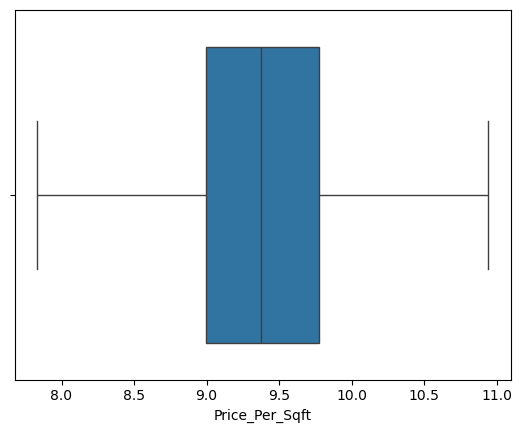

In [64]:
sns.boxplot(data = num_columns , x = 'Price_Per_Sqft')

In [65]:
Q1 = num_columns['min_price_in_Lakhs'].quantile(0.25)
Q3 = num_columns['min_price_in_Lakhs'].quantile(0.75)

IQR = Q3 - Q1 

Lower = Q1 - 1.5 * IQR
Higher = Q3 + 1.5 * IQR 

outliers_in_price = num_columns[(num_columns['min_price_in_Lakhs'] <= Lower) | (num_columns['min_price_in_Lakhs'] >= Higher)]


num_columns['min_price_in_Lakhs'] = np.where(num_columns['min_price_in_Lakhs'] < Lower , Q1,
         np.where(num_columns['min_price_in_Lakhs'] > Higher , Q3 , num_columns['min_price_in_Lakhs']))

# capped outliers with lower value of outlier and upper value of outliers 



In [66]:
outliers_in_price.shape
# Shape of the outliers

(261, 11)

<Axes: xlabel='min_price_in_Lakhs'>

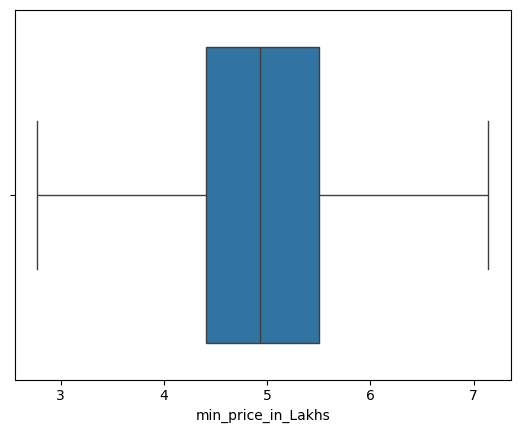

In [67]:
sns.boxplot(data = num_columns , x = 'min_price_in_Lakhs')

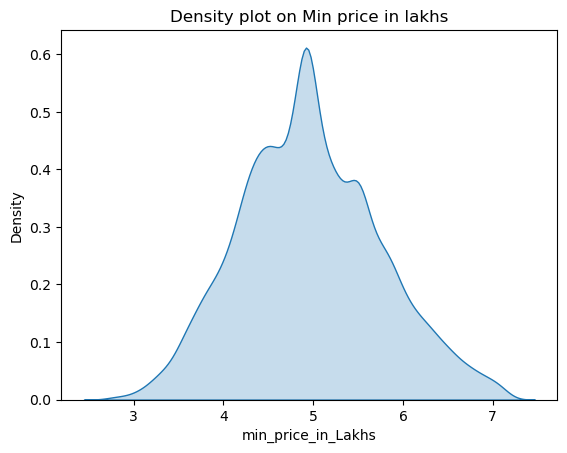

In [68]:
sns.kdeplot(data = num_columns , x = 'min_price_in_Lakhs', fill = True)
plt.title('Density plot on Min price in lakhs')
plt.show()

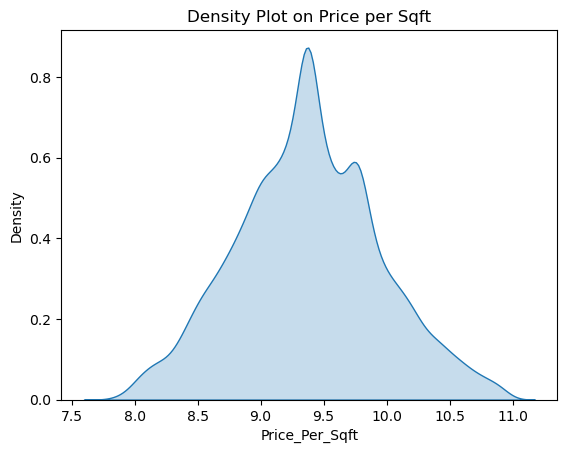

In [69]:
sns.kdeplot(data = num_columns , x = 'Price_Per_Sqft', fill = True)
plt.title('Density Plot on Price per Sqft')
plt.show()

In [70]:
num_columns.groupby(cat_columns['regions'])[['Price_Per_Sqft','min_price_in_Lakhs']].agg(['min','max','mean','std','var'])

Price_Per_Sqft                                            \
                         min        max       mean       std       var   
regions                                                                  
Bangalore           7.873217  10.925165   9.273568  0.520943  0.271382   
Beyond thane        7.833996  10.758243   8.934870  0.406329  0.165103   
Greater noida       7.849714  10.819798   9.007954  0.471239  0.222066   
Gurgaon             7.837554  10.937579   9.578692  0.465925  0.217087   
Mumbai              7.975908  10.939604  10.234384  0.428723  0.183804   
Navi mumbai         7.952263  10.929798   9.444337  0.466402  0.217531   
New delhi           7.929846  10.940756   9.475273  0.608010  0.369676   
Noida               7.865955  10.936672   9.250889  0.535245  0.286488   
Pune                8.040125  10.657283   9.311389  0.373787  0.139717   
Thane               8.005701  10.885940   9.791711  0.345380  0.119287   
Unknown             9.372969   9.372969   9.372969  0.000000  0.000000   

              min_price_in_Lakhs                                          
                             min       max      mean       std       var  
regions                                                                   
Bangalore               2.821379  7.138073  5.104416  0.716518  0.513398  
Beyond thane            2.772589  6.584791  4.087278  0.501376  0.251378  
Greater noida           2.833213  6.929517  4.642296  0.644578  0.415480  
Gurgaon                 2.995732  7.131699  5.432716  0.771010  0.594456  
Mumbai                  3.433987  7.131699  5.638748  0.648196  0.420157  
Navi mumbai             3.139833  7.090910  4.677197  0.616923  0.380594  
New delhi               2.772589  7.143618  4.953657  0.950442  0.903341  
Noida                   2.827314  7.131699  5.022664  0.808796  0.654151  
Pune                    2.944439  7.003974  4.762049  0.661063  0.437005  
Thane                   3.025291  7.131699  4.921237  0.521360  0.271817  
Unknown                 4.927254  4.927254  4.927254  0.000000  0.000000

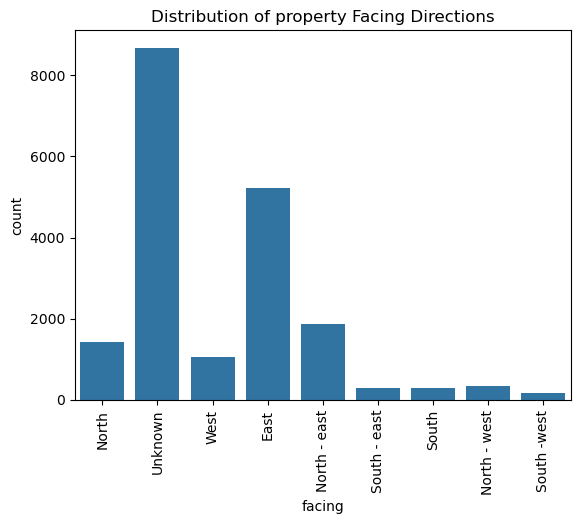

In [71]:
sns.countplot(data = df2 , x = 'facing')
plt.xticks(rotation = 90)
plt.title('Distribution of property Facing Directions')
plt.show()

- In Unknown direction there are 8000+ properties are listed
- In South-west direction there are very less (500) properties are listed
- In east direction there are around 5300 properties are listed  

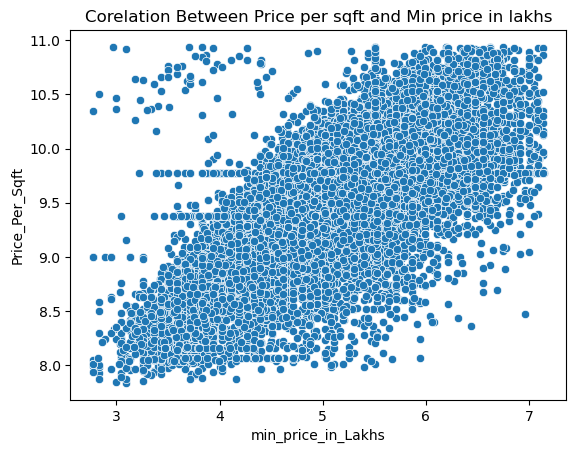

In [72]:
sns.scatterplot(data = num_columns , x = 'min_price_in_Lakhs', y = 'Price_Per_Sqft')
plt.title('Corelation Between Price per sqft and Min price in lakhs')
plt.show()

In [73]:
cat_columns['Residency_Type'].nunique()

5

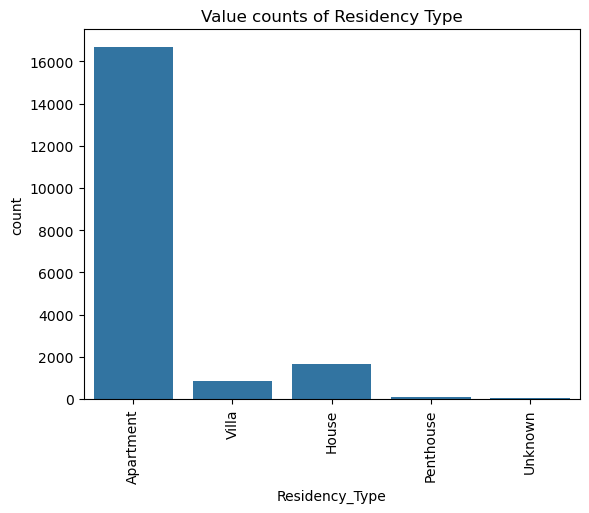

In [74]:
sns.countplot(data = df2 , x = 'Residency_Type')
plt.title('Value counts of Residency Type')
plt.xticks(rotation = 90)
plt.show()

- The Residency type (Apartment) has more properties about 16500
- The penthouses are very less amoung all the residency types about 300 - 400
- there are very less Unknown Residency type approximately below 100

In [75]:
df2['Residency_Type'].value_counts()

Residency_Type
Apartment    16677
House         1657
Villa          877
Penthouse      110
Unknown         31
Name: count, dtype: int64

# Identify patterns in buyer demand by analyzing property features (bhk, super_built_up_area, carpet_area, furnished_status, facing, etc.).


In [76]:
num_columns.columns

Index(['bhk', 'super_built_up_area', 'carpet_area', 'Price_Per_Sqft',
       'Charge_Amount', 'avl_bedroom', 'avl_bathroom', 'balconies',
       'Total_Floors', 'Floor_num', 'min_price_in_Lakhs'],
      dtype='object')

In [77]:
cat_columns.columns

Index(['projectName', 'Residency_Type', 'status', 'Charge_Type',
       'Furnished_Status', 'Property_Status', 'facing', 'localities',
       'additional_room', 'regions'],
      dtype='object')

# Non Visualization

In [78]:
def categorical_Analysis(col):
    unique = cat_columns[col].unique()
    Frequency_head = cat_columns[col].value_counts().head(30)
    #Frequency_tail = cat_columns[col].value_counts().tail(30)
    no_of_unique_Values = cat_columns[col].nunique()
    mode = cat_columns[col].mode()

    print(f"Unique values in {col} are :\n" ,unique)
    print()
    print(f'Frequency of first 30 Unique values in  {col} are:\n',Frequency_head)
    print()
    #print(f'Frequency of last 30 Unique values in {col} are:\n',Frequency_tail)
    #print()
    print(f'No.of unique values in {col} are:\n',no_of_unique_Values)
    print()
    print(f'Mode of the {col} is:\n',mode)

def numeical_Analysis(col):
    discribe = num_columns[col].describe()
    skewness = num_columns[col].skew()
    kurtosis = num_columns[col].kurt()

    print(f'Describing about {col}:\n',discribe)
    print()
    print(f'Skewness of {col} : \n',skewness)
    print()
    print(f'kurtosis of {col} :\n',kurtosis)
    

In [79]:
categorical_Analysis('Furnished_Status')

Unique values in Furnished_Status are :
 ['Unfurnished' 'Unknown' 'Semi-furnished' 'Furnished']

Frequency of first 30 Unique values in  Furnished_Status are:
 Furnished_Status
Unfurnished       7953
Semi-furnished    6656
Unknown           2469
Furnished         2274
Name: count, dtype: int64

No.of unique values in Furnished_Status are:
 4

Mode of the Furnished_Status is:
 0    Unfurnished
Name: Furnished_Status, dtype: object


In [80]:
categorical_Analysis('facing')

Unique values in facing are :
 ['North' 'Unknown' 'West' 'East' 'North - east' 'South - east' 'South'
 'North - west' 'South -west']

Frequency of first 30 Unique values in  facing are:
 facing
Unknown         8680
East            5231
North - east    1874
North           1425
West            1043
North - west     339
South            299
South - east     285
South -west      176
Name: count, dtype: int64

No.of unique values in facing are:
 9

Mode of the facing is:
 0    Unknown
Name: facing, dtype: object


In [81]:
numeical_Analysis('bhk')

Describing about bhk:
 count    19352.000000
mean         2.828235
std          1.040323
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          9.000000
Name: bhk, dtype: float64

Skewness of bhk : 
 2.0295312912781016

kurtosis of bhk :
 6.860468131461204


**Positive Skewness is 2.02 meaning that few properties with very high BHK like (7,8,9) pulling the tail to the right This suggests that they are Outliers at higher side**

**Kurtosis > 3 -- Lepto Kurtic Distribution meaning that the distribution has heavy tails and sharp peak compared to a normal distribution**

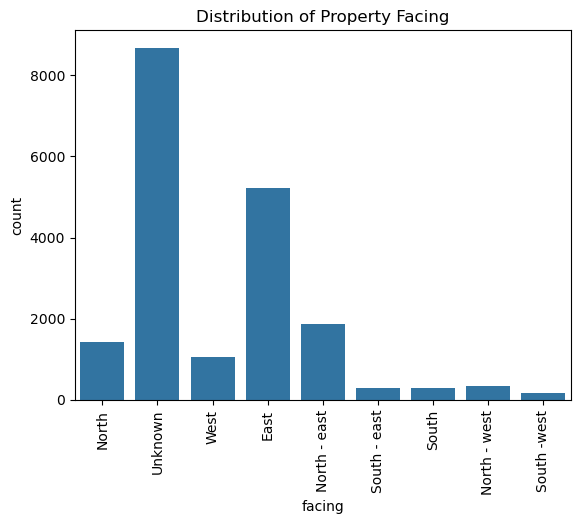

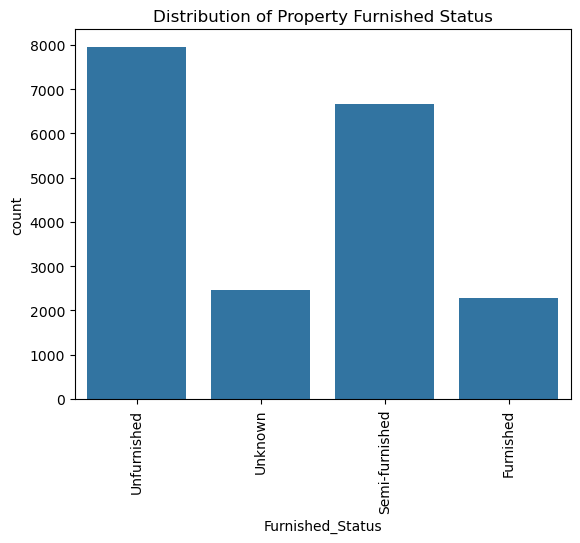

In [82]:
sns.countplot(data = cat_columns , x = 'facing')
plt.xticks(rotation = 90)
plt.title('Distribution of Property Facing')
plt.show()

sns.countplot(data = cat_columns , x = 'Furnished_Status')
plt.xticks(rotation = 90)
plt.title('Distribution of Property Furnished Status')
plt.show()

- East facing properties are above 7000
- South - east facing properties are very less below 500
- Unknown facing properties are more there are above 8500

In [83]:
Q1 = num_columns['bhk'].quantile(0.25)
Q3 = num_columns['bhk'].quantile(0.75)

IQR = Q3 - Q1 

Lower = Q1 - 1.5 * IQR
Higher = Q3 + 1.5 * IQR 

outliers_in_BHK = num_columns[(num_columns['bhk'] <= Lower) | (num_columns['bhk'] >= Higher)]


num_columns['bhk'] = np.where(num_columns['bhk'] < Lower , Lower,
         np.where(num_columns['bhk'] > Higher , Higher , num_columns['min_price_in_Lakhs']))



In [84]:
outliers_in_price.shape

(261, 11)

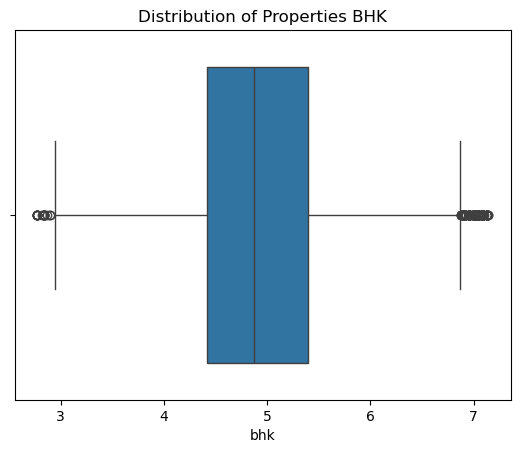

In [85]:
sns.boxplot(data = num_columns , x = 'bhk')
plt.title('Distribution of Properties BHK')
plt.show()

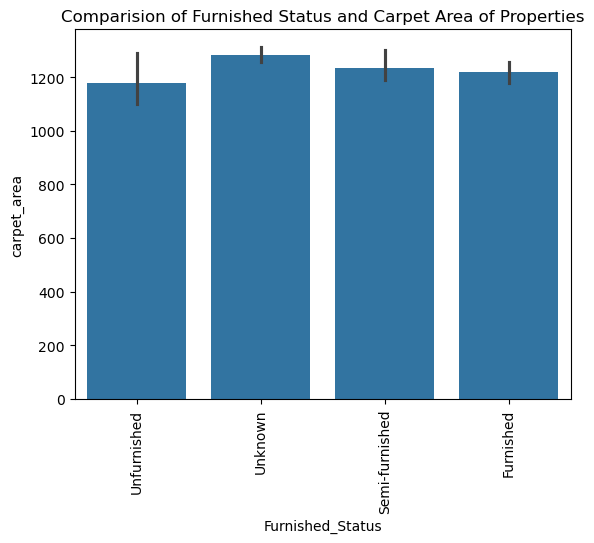

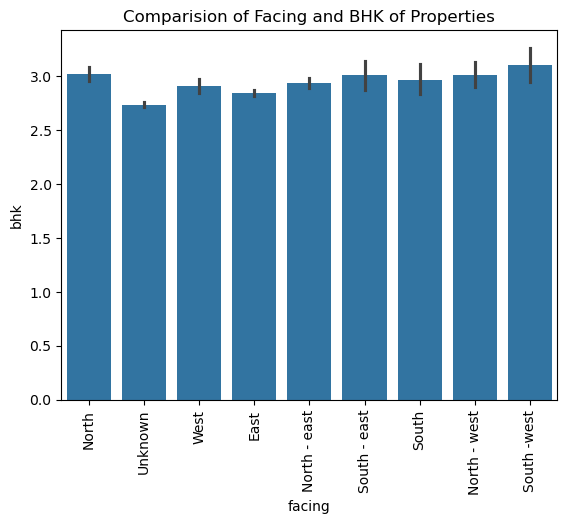

In [86]:

sns.barplot(data =  df2 , x = 'Furnished_Status', y = 'carpet_area')
plt.title('Comparision of Furnished Status and Carpet Area of Properties')
plt.xticks(rotation = 90)
plt.show()

sns.barplot(data =  df2 , x = 'facing', y = 'bhk')
plt.title('Comparision of Facing and BHK of Properties')
plt.xticks(rotation = 90)
plt.show()

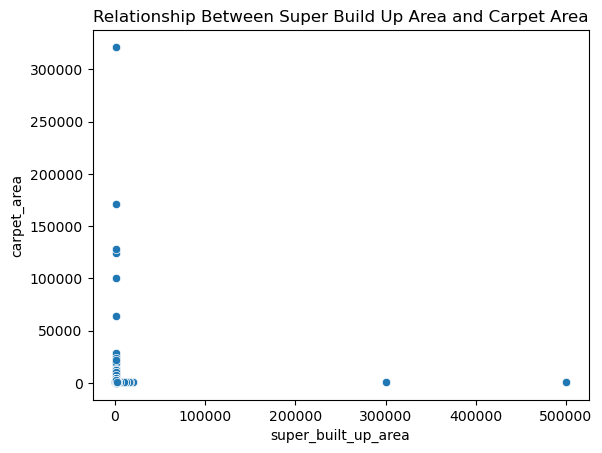

In [87]:
sns.scatterplot(data = num_columns , x = 'super_built_up_area', y = 'carpet_area')
plt.title('Relationship Between Super Build Up Area and Carpet Area')
plt.show()

# Determine high-demand localities and regions to prioritize marketing and new construction projects.


In [88]:
cat_columns.columns

Index(['projectName', 'Residency_Type', 'status', 'Charge_Type',
       'Furnished_Status', 'Property_Status', 'facing', 'localities',
       'additional_room', 'regions'],
      dtype='object')

In [89]:
cat_columns['localities'].value_counts(ascending = False).head(30)

localities
Unknown                  1157
Noida extension           660
Whitefield                358
Dombivli east             334
Panvel                    212
Kharghar                  210
Sarjapur road             199
Ghodbunder road           178
Dombivli                  141
Ambernath                 127
Sector 150                116
Hebbal                    114
Ulwe                      110
Yelahanka                 110
Thanisandra               103
Taloja                     99
Kolshet road               94
Yamuna expressway          91
Hennur main road           87
Badlapur                   87
Kalyan                     86
Thanisandra main road      85
Thane west                 78
Majiwada                   76
Kalyan west                74
Baner                      74
Varthur                    70
Mulund west                70
New panvel                 69
Kanakapura road            68
Name: count, dtype: int64

In [90]:
cat_columns['regions'].value_counts()

regions
Bangalore        6141
Beyond thane     1484
Navi mumbai      1469
New delhi        1463
Noida            1459
Mumbai           1439
Greater noida    1437
Pune             1429
Gurgaon          1353
Thane             908
Unknown           770
Name: count, dtype: int64

<Axes: xlabel='facing'>

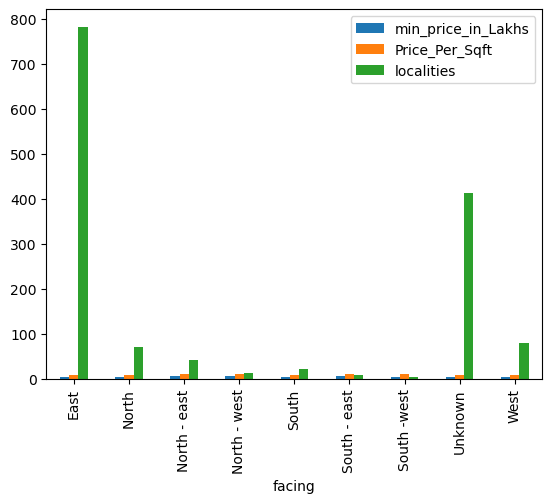

In [91]:
data = pd.concat([cat_columns , num_columns], axis = 1)

DataGroupBy = pd.DataFrame(data.groupby(['regions', 'facing']).agg({'min_price_in_Lakhs': 'mean','Price_Per_Sqft' : 'mean', 'localities' : 'count'}))

DataGroupBy

PuneData = DataGroupBy.loc['Pune']

PuneData.plot(kind = 'bar')

In [92]:
data[(data['Property_Status'] == 'New Property') & (data['Charge_Type'] == 'Registration charges')].shape

(0, 21)

<Figure size 2500x800 with 0 Axes>

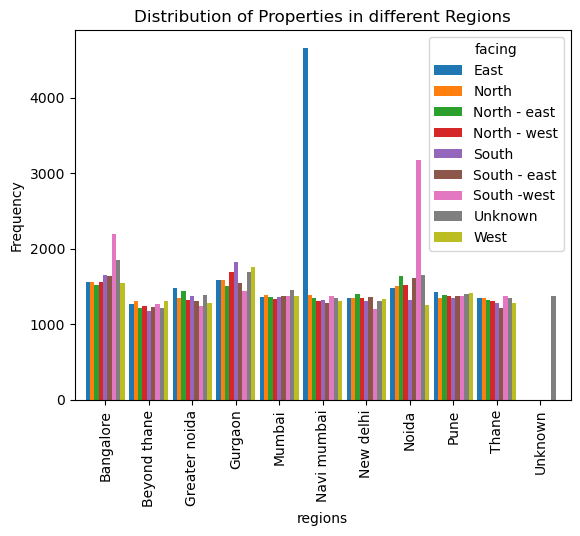

In [94]:
crosstab = pd.crosstab(index = cat_columns['regions'], columns = cat_columns['facing'],values = num_columns['super_built_up_area'], aggfunc=  'mean') 
plt.figure(figsize=(25,8))
crosstab.plot(kind = 'bar',width = 0.9)
plt.ylabel('Frequency')
plt.title("Distribution of Properties in different Regions")
plt.show()

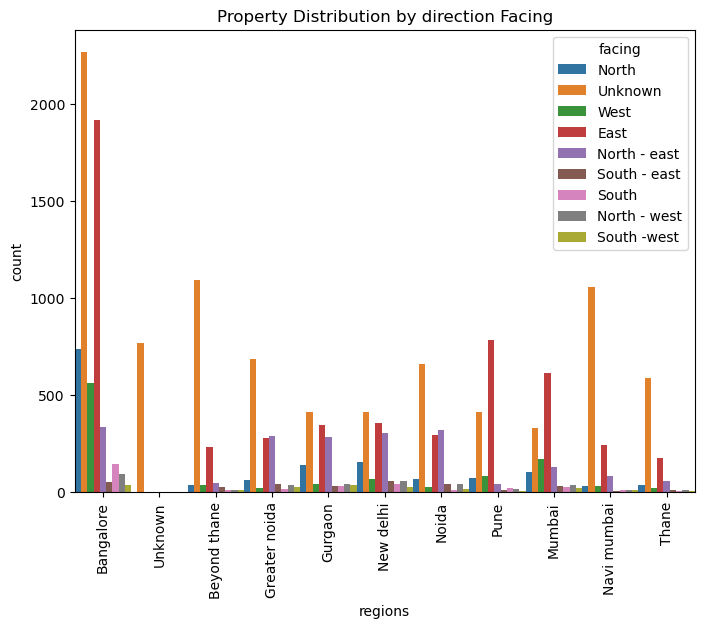

In [95]:
plt.figure(figsize = (8,6))
sns.countplot(data = cat_columns , x = 'regions', hue = 'facing',width = 1.0)
plt.xticks(rotation = 90)
plt.title('Property Distribution by direction Facing')
plt.show()

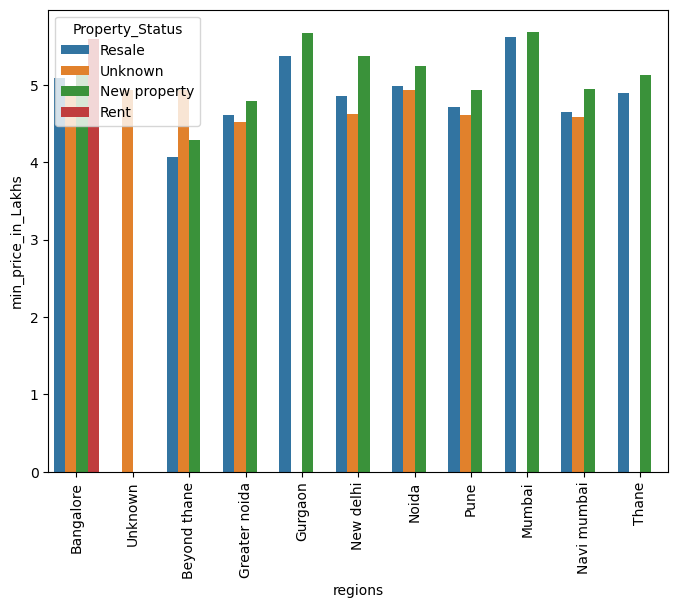

In [603]:
plt.figure(figsize= (8,6))
sns.barplot(data = cat_columns , x  = 'regions' , y = num_columns['min_price_in_Lakhs'] ,hue = 'Property_Status',ci = None)
plt.xticks(rotation = 90)
plt.show()

In [96]:
region_counts = cat_columns['regions'].value_counts()

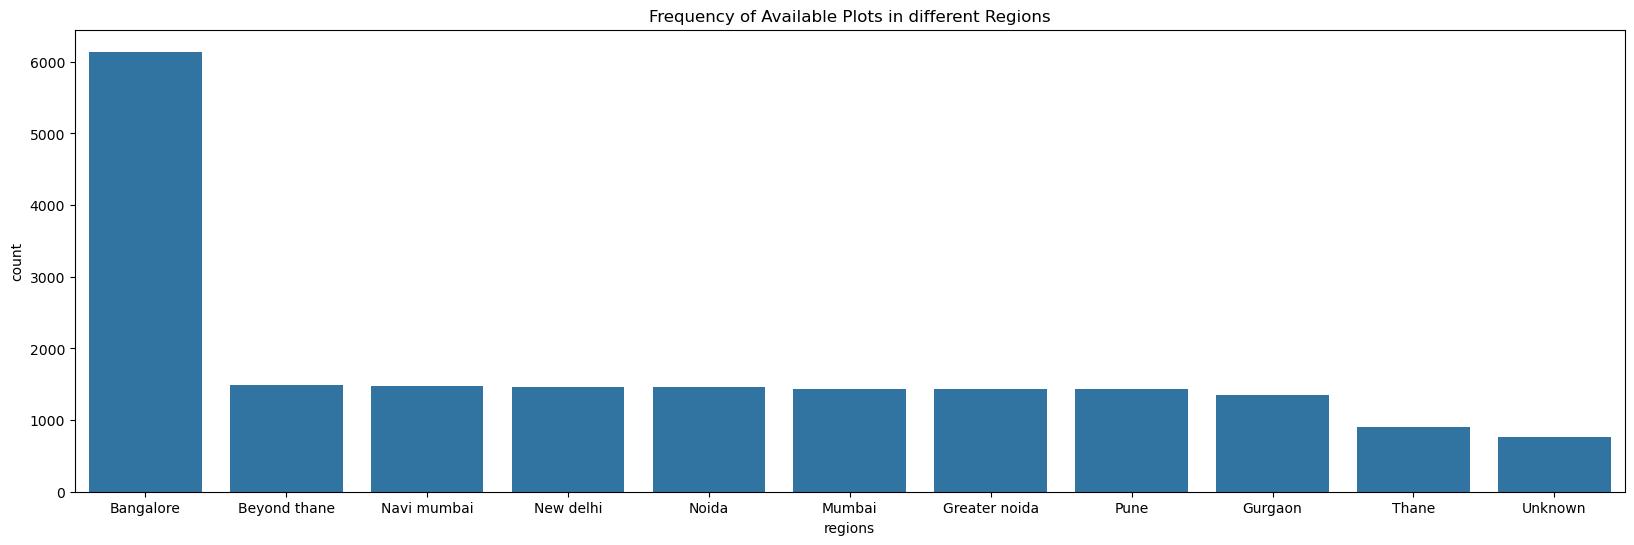

In [100]:
plt.figure(figsize= (20,6))
sns.barplot(data = region_counts)
plt.title("Frequency of Available Plots in different Regions")
plt.show()

In [101]:
region_counts

regions
Bangalore        6141
Beyond thane     1484
Navi mumbai      1469
New delhi        1463
Noida            1459
Mumbai           1439
Greater noida    1437
Pune             1429
Gurgaon          1353
Thane             908
Unknown           770
Name: count, dtype: int64

# Detect anomalies or outliers in pricing to avoid overpricing/underpricing properties.

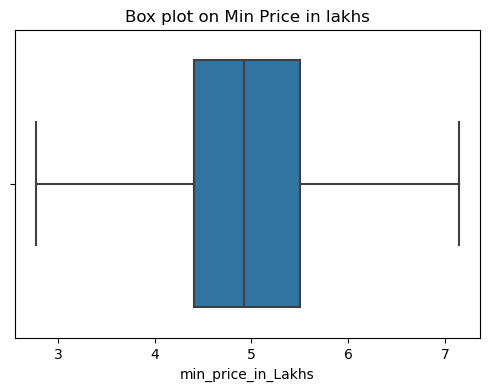

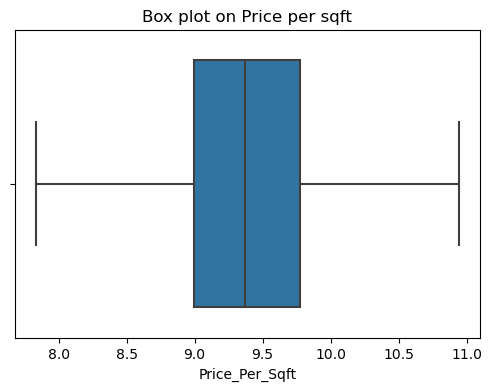

In [655]:
plt.figure(figsize= (6,4))
sns.boxplot(data = num_columns , x = 'min_price_in_Lakhs')
plt.title('Box plot on Min Price in lakhs')
plt.show()

plt.figure(figsize = (6,4))
sns.boxplot(data = num_columns, x = 'Price_Per_Sqft')
plt.title('Box plot on Price per sqft')
plt.show()

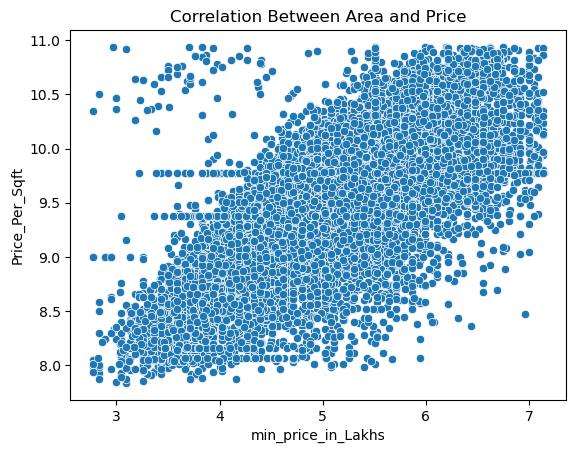

In [656]:
sns.scatterplot(data = num_columns , x = 'min_price_in_Lakhs', y = 'Price_Per_Sqft')
plt.title('Correlation Between Area and Price')
plt.show()

# Segment the market based on property type, size, and location to tailor offerings.


In [102]:
location_group = data.groupby(['regions']).agg({'min_price_in_Lakhs':'mean','localities':'count'}).reset_index()

In [103]:
location_group

,regions,min_price_in_Lakhs,localities
0,Bangalore,5.104416,6141
1,Beyond thane,4.087278,1484
2,Greater noida,4.642296,1437
3,Gurgaon,5.432716,1353
4,Mumbai,5.638748,1439
5,Navi mumbai,4.677197,1469
6,New delhi,4.953657,1463
7,Noida,5.022664,1459
8,Pune,4.762049,1429
9,Thane,4.921237,908


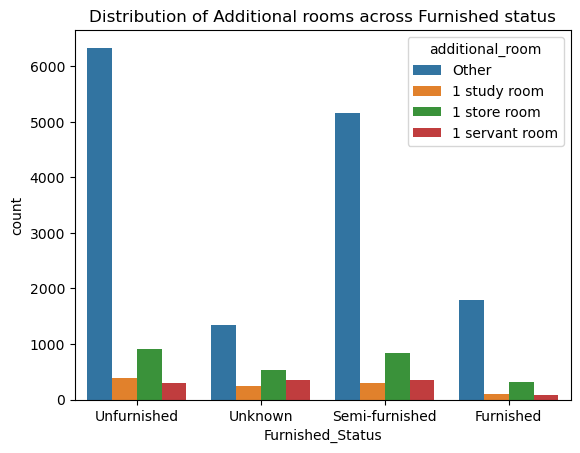

In [104]:
sns.countplot(data = cat_columns , x = 'Furnished_Status', hue = 'additional_room')
plt.title('Distribution of Additional rooms across Furnished status')
plt.show()

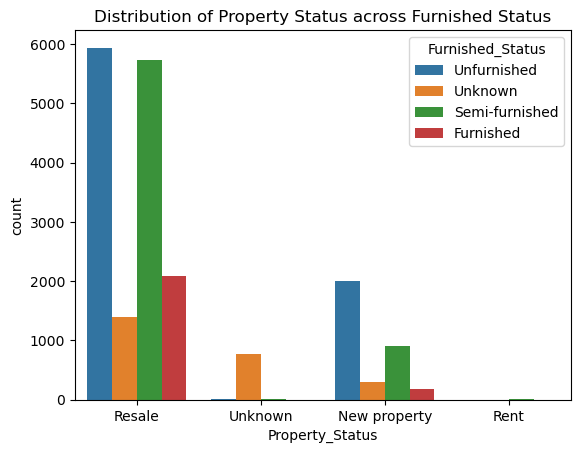

In [105]:
sns.countplot(data = cat_columns , x = 'Property_Status', hue = 'Furnished_Status')
plt.title('Distribution of Property Status across Furnished Status')
plt.show()

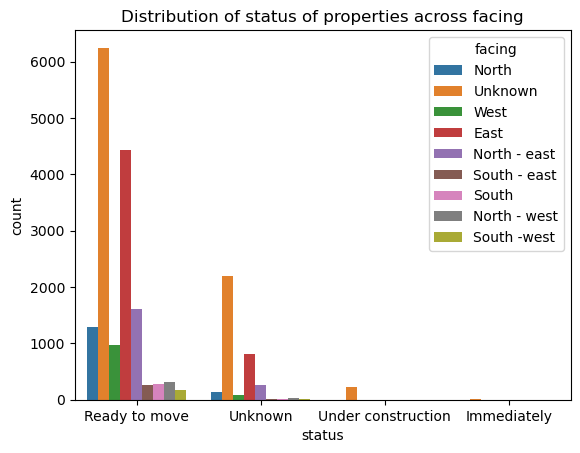

In [106]:
sns.countplot(data = cat_columns, x = 'status', hue = 'facing')
plt.title('Distribution of status of properties across facing')
plt.show()

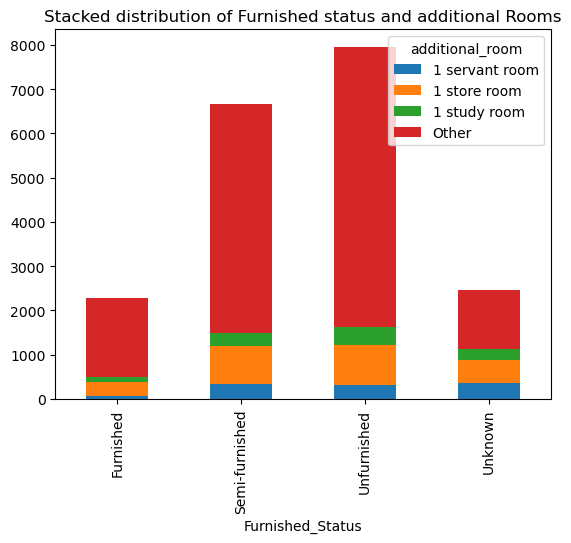

In [107]:
pd.crosstab(index = cat_columns['Furnished_Status'],columns= cat_columns['additional_room']).plot(kind = 'bar',stacked = True )
plt.title('Stacked distribution of Furnished status and additional Rooms')
plt.show()

- There are more unfurnished properties with additional rooms except servent room , store room , study room & less study rooms available
- there are very less furnished properties in that also there are very lessservent rooms & study rooms
- Unknown furnished status properties has more servent rooms & less study rooms available

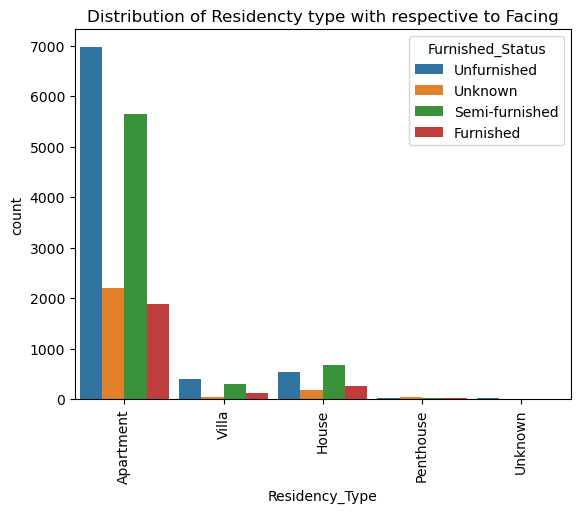

In [108]:
sns.countplot(data = cat_columns , x = 'Residency_Type', hue = 'Furnished_Status',width= 0.9)
plt.title('Distribution of Residencty type with respective to Facing')
plt.xticks(rotation = 90)
plt.show()

- There are more unfurnished status properties are in Apartment type
- Penthouses are very less with unfurnished

# Non Visualization Analysis 

In [122]:
def categorical_Analysis(col):
    unique = cat_columns[col].unique()
    Frequency_head = cat_columns[col].value_counts().head(30)
    Frequency_tail = cat_columns[col].value_counts().tail(30)
    no_of_unique_Values = cat_columns[col].nunique()
    mode = cat_columns[col].mode()

    print(f"Unique values in {col} are :\n" ,unique)
    print()
    print("***********"* 5)
    print(f'Frequency of first 30 Unique values in  {col} are:\n',Frequency_head)
    print()
    print("***********"* 5)
    print(f'Frequency of last 30 Unique values in {col} are:\n',Frequency_tail)
    print()
    print("***********"* 5)
    print(f'No.of unique values in {col} are:\n',no_of_unique_Values)
    print()
    print("***********"* 5)
    print(f'Mode of the {col} is:\n',mode)

def numeical_Analysis(col):
    discribe = num_columns[col].describe()
    skewness = num_columns[col].skew()
    kurtosis = num_columns[col].kurt()

    print(f'Describing about {col}:\n',discribe)
    print()
    print("***********"* 5)
    print(f'Skewness of {col} : \n',skewness)
    print()
    print("***********"* 5)
    print(f'kurtosis of {col} :\n',kurtosis)

    

In [115]:
for i in cat_columns.columns:
    categorical_Analysis(i)

Unique values in projectName are :
 ['Unknown' 'Dsr the address' 'Sri sai nandana royal' ...
 'Sri sai paradise' 'Vega east woods' 'Ravoos nandan']

*******************************************************
Frequency of first 30 Unique values in  projectName are:
 projectName
Unknown                      7522
Lodha amara                    54
Lodha splendora                39
Purva atmosphere               35
Godrej tropical isle           30
Sobha dream gardens            30
Indiabulls greens panvel       28
Godrej woods                   28
Tata amantra                   28
Supertech capetown             27
Runwal mycity                  24
Lodha lakeshore greens         24
Piramal vaikunth               23
Lodha palava                   23
Runwal garden city             22
Lodha palava city              22
Mohan suburbia                 22
Amrapali golf homes            21
Prestige lakeside habitat      20
Panchsheel greens 2            20
Brigade el dorado              19
Sobha winds

In [123]:
for i in num_columns.columns:
    numeical_Analysis(i)
    

Describing about bhk:
 count    19352.000000
mean         4.904728
std          0.753370
min          2.772589
25%          4.412798
50%          4.875197
75%          5.398163
max          7.143618
Name: bhk, dtype: float64

*******************************************************
Skewness of bhk : 
 0.2917448489726592

*******************************************************
kurtosis of bhk :
 -0.09796027456339562
Describing about super_built_up_area:
 count     19352.000000
mean       1531.716722
std        4243.964817
min          30.000000
25%        1375.000000
50%        1375.000000
75%        1375.000000
max      500000.000000
Name: super_built_up_area, dtype: float64

*******************************************************
Skewness of super_built_up_area : 
 101.75456227202503

*******************************************************
kurtosis of super_built_up_area :
 11099.346030786617
Describing about carpet_area:
 count     19352.000000
mean       1214.601023
std        3142.4